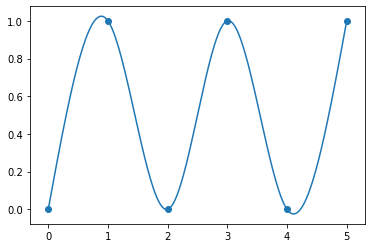

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], float)
y = np.array([0, 1, 0, 1, 0, 1], float)

n = len(x)
h = np.diff(x)

A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

B[0] = 1
B[-1] = 1

for i in range(1, n-1):
    A[i] = h[i-1]
    B[i] = 2 * (h[i-1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

for i in range(1, n):
    w = A[i] / B[i-1]
    B[i] -= w * C[i-1]
    D[i] -= w * D[i-1]

M = np.zeros(n)
M[-1] = D[-1] / B[-1]

for i in range(n-2, -1, -1):
    M[i] = (D[i] - C[i] * M[i+1]) / B[i]

def S(xe):
    for i in range(n-1):
        if x[i] <= xe <= x[i+1]:
            hi = h[i]
            return (
                M[i]*(x[i+1]-xe)**3/(6*hi)
                + M[i+1]*(xe-x[i])**3/(6*hi)
                + (y[i]-M[i]*hi**2/6)*(x[i+1]-xe)/hi
                + (y[i+1]-M[i+1]*hi**2/6)*(xe-x[i])/hi
            )

xs = np.linspace(x.min(), x.max(), 200)
ys = [S(xi) for xi in xs]

plt.plot(xs, ys)
plt.scatter(x, y)
plt.show()